# Diputrax V0 — Diagnóstico de supuestos de regresión lineal clásica

**Naturaleza de este cuaderno.** `diputraxv0.ipynb` es un cuaderno **previo y complementario** a `diputraxv10.ipynb`; **no reemplaza ni modifica** ninguna celda de v10. Replica el pipeline de datos de v10 (MICE + *feature engineering*, `FEAT_COLS`) de forma idéntica y autocontenida, y evalúa si los datos —tal como entran al pipeline de modelado de v10— satisfacen los siete supuestos clásicos de la regresión lineal (Gauss-Markov + normalidad):

1. Linealidad
2. Homoscedasticidad
3. Independencia de los errores
4. Normalidad de los residuos
5. No multicolinealidad
6. Exogeneidad
7. Ausencia de valores atípicos influyentes

**Por qué "V0".** v10 modela `nodal_bin` y `lastre_bin` con Regresión Logística (L1/L2) y `n_comisiones_tematicas` con GLM Poisson — nunca con regresión lineal (OLS). Este cuaderno pregunta, como paso metodológico *previo* y lógicamente anterior a esa elección: *¿habría sido válido usar OLS sobre estos datos?* Ajusta un **Modelo de Probabilidad Lineal (MPL)** —OLS sobre un *target* binario 0/1— para `nodal_bin` y `lastre_bin`, y una regresión lineal simple para `n_comisiones_tematicas`, y somete a los 12 modelos resultantes (3 *targets* × 4 eras) a la batería clásica de diagnósticos. El resultado es evidencia empírica —no solo una convención de la disciplina— de por qué v10 usa GLM en lugar de OLS.

**Alcance.** Se usa el conjunto **completo** `FEAT_COLS` (64 variables) estandarizado por era, no el subconjunto `SelectFromModel` de v10 — el objetivo es diagnosticar los *datos*, no reproducir la especificación final de cada modelo de v10.


## 1. Introducción y objetivo

La Regresión Lineal por Mínimos Cuadrados Ordinarios (OLS) produce estimadores insesgados y de mínima varianza —Gauss-Markov— y permite inferencia clásica (valores *p*, intervalos de confianza) solo bajo un conjunto de supuestos sobre los datos y los errores del modelo. Cuando el *target* es binario (0/1) —como `nodal_bin` y `lastre_bin`— usar OLS se conoce como **Modelo de Probabilidad Lineal (MPL)**: es interpretable (el coeficiente es un efecto marginal directo sobre la probabilidad) pero **viola estructuralmente** varios de estos supuestos por construcción, no por mala suerte muestral. Este cuaderno lo demuestra empíricamente, variable por variable y era por era, en lugar de asumirlo.

### 1.1 Los siete criterios evaluados

| # | Criterio | Qué significa | Prueba(s) usada(s) | Umbral de decisión |
|---|---|---|---|---|
| 1 | Linealidad | La relación entre predictores y *target* es lineal en los parámetros | RESET (Ramsey) | *p* < 0.05 → se rechaza linealidad |
| 2 | Homoscedasticidad | La varianza del error es constante para todo nivel de los predictores | Breusch-Pagan + White simplificado (Wooldridge) | *p* < 0.05 → heterocedasticidad |
| 3 | Independencia de errores | Los errores no están correlacionados entre observaciones | Durbin-Watson (orden por legislatura) + ANOVA de residuos por estado | DW lejos de 2 o ANOVA *p* < 0.05 → dependencia |
| 4 | Normalidad de residuos | Los residuos siguen una distribución normal | Shapiro-Wilk + Jarque-Bera | *p* < 0.05 → no normalidad |
| 5 | No multicolinealidad | Los predictores no son combinaciones (casi) exactas entre sí | VIF (*Variance Inflation Factor*) + número de condición | VIF > 10 → colinealidad severa |
| 6 | Exogeneidad | El error no está correlacionado con los predictores, `E[ε\|X]=0` | No computable sin variables instrumentales — discusión cualitativa | — |
| 7 | Ausencia de atípicos influyentes | Ninguna observación domina desproporcionadamente el ajuste | Distancia de Cook, *leverage*, DFFITS | Cook's D > 4/n → observación influyente |

Los doce modelos —3 *targets* × 4 eras— se ajustan sobre las variables **estandarizadas** (`StandardScaler`, igual que el pipeline productivo de v10) para que los coeficientes y diagnósticos sean comparables entre variables y eras.


## 2. Configuración y pipeline de datos (idéntico a diputraxv10)

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as scistats
from IPython.display import display

import statsmodels.api as sm
from statsmodels.stats.diagnostic import linear_reset, het_breuschpagan
from statsmodels.stats.stattools import durbin_watson, jarque_bera
from statsmodels.stats.outliers_influence import variance_inflation_factor, OLSInfluence
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", context="talk", palette="deep")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.4f}".format)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PARQUET = PROJECT_ROOT / "data" / "clean" / "diputados_20260421_205712.parquet"
REPORT_DIR = PROJECT_ROOT / "reports" / "eda"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

ERA_MAP = {
    57: "ERA_1_PRI",  58: "ERA_1_PRI",  59: "ERA_1_PRI",
    60: "ERA_2_PAN",  61: "ERA_2_PAN",  62: "ERA_2_PAN",
    63: "ERA_3_TRANS", 64: "ERA_3_TRANS", 65: "ERA_3_TRANS",
    66: "ERA_4_MORENA",
}
ERA_ORDER = ["ERA_1_PRI", "ERA_2_PAN", "ERA_3_TRANS", "ERA_4_MORENA"]
ERA_LABELS = {
    "ERA_1_PRI":    "ERA 1 - PRI (57-59)",
    "ERA_2_PAN":    "ERA 2 - PAN (60-62)",
    "ERA_3_TRANS":  "ERA 3 - Transicion (63-65)",
    "ERA_4_MORENA": "ERA 4 - Morena (66)",
}
TOP_PARTIDOS = ["PRI", "PAN", "MORENA", "PRD", "PVEM", "PT", "MC"]

raw = pd.read_parquet(PARQUET)
print(f"Fuente: {PARQUET.name}  |  shape: {raw.shape}")


Fuente: diputados_20260421_205712.parquet  |  shape: (5000, 79)


In [2]:
# ============================================================
# MICE — Imputacion de edad_al_tomar_cargo (identico a v10, celda 4.3)
# ============================================================
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer

MICE_COND_VARS = [
    'legislatura_num', 'n_cargos_legislativos_prev', 'fue_diputado_local',
    'fue_diputado_federal', 'fue_senador', 'n_trayectoria_legislativa',
    'n_trayectoria_admin', 'nivel_cargo_max', 'fue_presidente_mun',
    'fue_secretario_cargo', 'fue_director_general', 'fue_subsecretario',
    'admin_en_gobierno_fed', 'admin_en_gobierno_est', 'admin_en_gobierno_mun',
    'edad_al_tomar_cargo',
]
mice_cols = [c for c in MICE_COND_VARS if c in raw.columns]
mice_imputer = IterativeImputer(max_iter=10, random_state=42,
                                 initial_strategy='mean', skip_complete=True)
mice_result = mice_imputer.fit_transform(raw[mice_cols].copy())
mice_df = pd.DataFrame(mice_result, columns=mice_cols, index=raw.index)

raw['edad_missing'] = raw['edad_al_tomar_cargo'].isna().astype(int)
raw['edad_imp'] = np.where(
    raw['edad_al_tomar_cargo'].isna(),
    mice_df['edad_al_tomar_cargo'].clip(18, 90),
    raw['edad_al_tomar_cargo'],
)
print(f"Registros imputados: {int(raw['edad_missing'].sum())} "
      f"({100*raw['edad_missing'].mean():.1f}%)")


Registros imputados: 510 (10.2%)


In [3]:
# ============================================================
# Feature engineering -> df_enc, FEAT_COLS (identico a v10, celda 4.3-4.4)
# ============================================================
df = raw.copy()
df["era"] = df["legislatura_num"].map(ERA_MAP)
df["nodal_bin"] = (df["n_comisiones_nodales"] >= 1).astype(int)
df["lastre_bin"] = (df["n_comisiones_lastre"] >= 1).astype(int)

REGION_MAP = {
    "CDMX": "CDMX",
    **dict.fromkeys(["MEX","HGO","MOR","PUE","TLAX","QRO","GTO","AGS"], "CENTRO"),
    **dict.fromkeys(["VER","OAX","CHIS","TAB","GRO","CAM","YUC","QROO"], "SUR"),
    **dict.fromkeys(["NL","TAMPS","COAH","CHIH","SON","BC","BCS","SIN",
                     "DGO","ZAC","SLP","NAY"], "NORTE"),
    **dict.fromkeys(["JAL","COL","MICH"], "OCCIDENTE"),
    "DESCONOCIDO": "RP",
}
df["region"] = df["entidad_codigo"].map(REGION_MAP).fillna("CENTRO")
df["partido_cat"] = df["partido"].where(df["partido"].isin(TOP_PARTIDOS), "OTRO")
df["univ_elite"] = df[["acad_unam","acad_itam","acad_ibero","acad_itesm"]].max(axis=1)
df["sexo_bin"] = (df["sexo"] == "M").astype(int)

_p    = pd.get_dummies(df["partido_cat"],     prefix="p")
_reg  = pd.get_dummies(df["region"],          prefix="reg")
_area = pd.get_dummies(df["area_formacion"],  prefix="area")
df_enc = pd.concat([df, _p, _reg, _area], axis=1)

NUMERIC_FEATS = [
    "sexo_bin",
    "edad_imp", "edad_missing",
    "mayoria_relativa", "es_partido_mayoria", "legislatura_num",
    "grado_estudios_ord", "tiene_posgrado", "tiene_doctorado",
    "estudios_en_extranjero", "univ_publica", "univ_privada", "univ_extranjera",
    "univ_elite",
    "n_cargos_legislativos_prev", "fue_diputado_local",
    "fue_diputado_federal", "fue_senador", "n_trayectoria_legislativa",
    "n_trayectoria_admin", "nivel_cargo_max",
    "fue_presidente_mun", "fue_presidente_org", "fue_director_general",
    "fue_secretario_cargo", "fue_subsecretario", "fue_director",
    "fue_coordinador", "fue_delegado", "fue_asesor", "fue_regidor", "fue_sindico",
    "admin_en_partido","admin_en_sindicato","admin_en_universidad",
    "admin_en_gobierno_fed","admin_en_gobierno_est","admin_en_gobierno_mun",
    "n_trayectoria_politica", "tiene_exp_juvenil",
    "lider_juvenil_partido","lider_juvenil_gobierno","miembro_org_juvenil",
    "nivel_liderazgo_juvenil",
    "n_trayectoria_empresarial","n_investigacion_docencia","n_organos_gobierno",
]
AREA_KEEP = [
    "area_Derecho",
    "area_Ciencias Políticas y Sociales",
    "area_Económico-Financiera",
]
DUMMY_FEATS = list(_p.columns) + list(_reg.columns) + [c for c in AREA_KEEP if c in df_enc.columns]
FEAT_COLS = NUMERIC_FEATS + DUMMY_FEATS
print(f"Features totales: {len(FEAT_COLS)}  (numericas={len(NUMERIC_FEATS)}, dummies={len(DUMMY_FEATS)})")

def get_Xy(era, target):
    mask = df_enc["era"] == era
    X = df_enc.loc[mask, FEAT_COLS].astype(float).reset_index(drop=True)
    y = df_enc.loc[mask, target].astype(float).reset_index(drop=True)
    # partido_cat ya entra al diseño como dummies (p_*): las medias de
    # residuo por partido son cero por construccion (X'e=0), asi que no
    # sirve como agrupador de independencia. entidad_codigo (estado) NO
    # entra al diseño -solo la region agregada, reg_*- por lo que si es
    # un agrupador legitimo para heterogeneidad no capturada por el modelo.
    entidad = df_enc.loc[mask, "entidad_codigo"].reset_index(drop=True)
    legis   = df_enc.loc[mask, "legislatura_num"].reset_index(drop=True)
    return X, y, entidad, legis

TARGETS = [
    ("nodal_bin", "Nodales (MPL)"),
    ("lastre_bin", "Lastre (MPL)"),
    ("n_comisiones_tematicas", "Temáticas (lineal)"),
]


Features totales: 64  (numericas=47, dummies=17)


## 3. Especificación de los modelos OLS diagnóstico

Se ajustan 12 modelos OLS —`statsmodels.OLS`, sin regularización— uno por combinación de *target* (`nodal_bin`, `lastre_bin`, `n_comisiones_tematicas`) × era (`ERA_1`–`ERA_4`), sobre el conjunto completo `FEAT_COLS` (64 variables) estandarizado + intercepto. Para `nodal_bin` y `lastre_bin` esto constituye un **Modelo de Probabilidad Lineal (MPL)**; para `n_comisiones_tematicas`, una regresión lineal simple sobre un conteo.


In [4]:
def fit_ols(era, target):
    X, y, entidad, legis = get_Xy(era, target)
    sc = StandardScaler()
    X_sc = pd.DataFrame(sc.fit_transform(X), columns=FEAT_COLS)
    X_design = sm.add_constant(X_sc, has_constant='add')
    res = sm.OLS(y, X_design).fit()
    return res, X_design, y, entidad, legis

fits = {}
rows_fit = []
for target_key, target_label in TARGETS:
    fits[target_key] = {}
    for era in ERA_ORDER:
        res, X_design, y, entidad, legis = fit_ols(era, target_key)
        fits[target_key][era] = {"res": res, "X_design": X_design,
                                  "entidad": entidad, "legis": legis}
        rows_fit.append({
            "Target": target_label, "Era": ERA_LABELS[era],
            "n": int(res.nobs), "k": int(res.df_model),
            "R2": round(res.rsquared, 3), "R2 ajust.": round(res.rsquared_adj, 3),
            "F": round(res.fvalue, 2), "F p-valor": res.f_pvalue,
            "AIC": round(res.aic, 1), "BIC": round(res.bic, 1),
        })

df_fit_summary = pd.DataFrame(rows_fit)
print("-- Ajuste OLS: 3 targets x 4 eras --")
display(df_fit_summary)


-- Ajuste OLS: 3 targets x 4 eras --


,Target,Era,n,k,R2,R2 ajust.,F,F p-valor,AIC,BIC
0,Nodales (MPL),ERA 1 - PRI (57-59),1500,56,0.2050,0.1750,6.6600,0.0000,1743.3000,2046.2000
1,Nodales (MPL),ERA 2 - PAN (60-62),1500,58,0.1920,0.1600,5.9200,0.0000,1922.6000,2236.1000
2,Nodales (MPL),ERA 3 - Transicion (63-65),1500,58,0.1810,0.1480,5.4700,0.0000,1996.6000,2310.1000
3,Nodales (MPL),ERA 4 - Morena (66),500,56,0.1900,0.0870,1.8500,0.0004,728.8000,969.0000
4,Lastre (MPL),ERA 1 - PRI (57-59),1500,56,0.0780,0.0420,2.1900,0.0000,2131.0000,2433.8000
5,Lastre (MPL),ERA 2 - PAN (60-62),1500,58,0.1270,0.0920,3.6100,0.0000,2082.1000,2395.6000
6,Lastre (MPL),ERA 3 - Transicion (63-65),1500,58,0.0940,0.0570,2.5700,0.0000,2147.6000,2461.1000
7,Lastre (MPL),ERA 4 - Morena (66),500,56,0.1440,0.0350,1.3300,0.0659,738.4000,978.7000
8,Temáticas (lineal),ERA 1 - PRI (57-59),1500,56,0.1280,0.0940,3.7700,0.0000,4159.5000,4462.4000
9,Temáticas (lineal),ERA 2 - PAN (60-62),1500,58,0.1300,0.0960,3.7300,0.0000,4350.2000,4663.7000


## 4. Linealidad — prueba RESET (Ramsey)

El *test* RESET (*Regression Equation Specification Error Test*) agrega potencias de los valores ajustados (ŷ², ŷ³) a la regresión y prueba su significancia conjunta. H₀: la forma funcional lineal es correcta. Rechazar (p < 0.05) indica que la relación real entre predictores y *target* no es lineal —esperable en `nodal_bin`/`lastre_bin`, cuya relación teórica correcta es una sigmoide (logit), no una recta—.


In [5]:
def diag_linearity(res):
    rt = linear_reset(res, power=3, test_type='fitted', use_f=True)
    return {"reset_F": float(rt.fvalue), "reset_p": float(rt.pvalue)}

rows_lin = []
for target_key, target_label in TARGETS:
    for era in ERA_ORDER:
        res = fits[target_key][era]["res"]
        d = diag_linearity(res)
        fits[target_key][era]["linearity"] = d
        rows_lin.append({
            "Target": target_label, "Era": ERA_LABELS[era],
            "RESET F": round(d["reset_F"], 3), "RESET p-valor": round(d["reset_p"], 4),
            "¿Rechaza linealidad? (p<0.05)": "SI" if d["reset_p"] < 0.05 else "no",
        })

df_linearity = pd.DataFrame(rows_lin)
display(df_linearity)


,Target,Era,RESET F,RESET p-valor,¿Rechaza linealidad? (p<0.05)
0,Nodales (MPL),ERA 1 - PRI (57-59),3.1870,0.0416,SI
1,Nodales (MPL),ERA 2 - PAN (60-62),3.6900,0.0252,SI
2,Nodales (MPL),ERA 3 - Transicion (63-65),2.9360,0.0534,no
3,Nodales (MPL),ERA 4 - Morena (66),2.0140,0.1346,no
4,Lastre (MPL),ERA 1 - PRI (57-59),0.6350,0.5299,no
5,Lastre (MPL),ERA 2 - PAN (60-62),3.6780,0.0255,SI
6,Lastre (MPL),ERA 3 - Transicion (63-65),1.5780,0.2067,no
7,Lastre (MPL),ERA 4 - Morena (66),1.4190,0.2431,no
8,Temáticas (lineal),ERA 1 - PRI (57-59),0.0280,0.9720,no
9,Temáticas (lineal),ERA 2 - PAN (60-62),6.4810,0.0016,SI


**Interpretación — Linealidad**

**Nodales (MPL):** RESET rechaza la linealidad en ERA_1 (*p*=0.042) y ERA_2 (*p*=0.025); ERA_3 es límite (*p*=0.053); ERA_4 no rechaza (*p*=0.135, aunque con *n*=500 la prueba tiene menos potencia). En 2–3 de 4 eras la forma funcional lineal es estadísticamente inadecuada para `nodal_bin`.

**Lastre (MPL):** solo ERA_2 rechaza (*p*=0.026); ERA_1, ERA_3 y ERA_4 no (*p*=0.53, 0.21, 0.24). La linealidad es menos problemática aquí que en nodales, consistente con el ajuste (R²) sistemáticamente más bajo de lastre en toda la serie — hay menos señal lineal *que capturar* incorrectamente.

**Temáticas (lineal):** solo ERA_2 rechaza (*p*=0.0016); ERA_1, ERA_3, ERA_4 no (*p*=0.97, 0.19, 0.57). Es razonable: `n_comisiones_tematicas` es un conteo con rango acotado (0–10) pero de variación más continua que un binario, por lo que una aproximación lineal es menos violatoria que en los MPL.

**Lectura conjunta:** la violación de linealidad es más severa exactamente donde se esperaría por teoría —el *target* binario `nodal_bin`—, y más leve en el *target* de conteo. Esto es consistente con, no independiente de, la elección de v10 de usar un enlace no lineal (logit para binarios, log para Poisson).


## 5. Homoscedasticidad — Breusch-Pagan y White

Breusch-Pagan regresiona los residuos al cuadrado sobre los predictores originales; White generaliza agregando términos cuadráticos y cruzados, pero con 64 predictores el White completo requiere más términos (64 + 64·65/2 ≈ 2,144) que observaciones — inviable. Se usa la **versión simplificada de White** (Wooldridge, 2015, §8.3): regresar los residuos al cuadrado sobre ŷ y ŷ², que captura la misma idea (¿la varianza del error depende del nivel ajustado?) con solo 2 regresores. H₀ en ambas pruebas: homoscedasticidad. Rechazar (*p* < 0.05) indica heterocedasticidad.

Para un MPL, la heterocedasticidad **no es un hallazgo empírico sorpresivo, es una propiedad matemática**: si y∈{0,1}, `Var(ε|X) = p(X)·(1-p(X))`, que depende necesariamente de X. Este bloque lo confirma directamente sobre los datos de v10.


In [6]:
def diag_homoscedasticity(res, X_design):
    resid = res.resid
    bp = het_breuschpagan(resid, X_design.values)
    yhat = res.fittedvalues
    Z = sm.add_constant(np.column_stack([yhat, yhat**2]))
    aux = sm.OLS(resid**2, Z).fit()
    return {"bp_lm": float(bp[0]), "bp_p": float(bp[1]),
            "white_F": float(aux.fvalue), "white_p": float(aux.f_pvalue)}

rows_het = []
for target_key, target_label in TARGETS:
    for era in ERA_ORDER:
        res = fits[target_key][era]["res"]
        X_design = fits[target_key][era]["X_design"]
        d = diag_homoscedasticity(res, X_design)
        fits[target_key][era]["homoscedasticity"] = d
        rows_het.append({
            "Target": target_label, "Era": ERA_LABELS[era],
            "Breusch-Pagan p": d["bp_p"], "White (simpl.) p": d["white_p"],
            "¿Heterocedastico? (BP o White p<0.05)":
                "SI" if (d["bp_p"] < 0.05 or d["white_p"] < 0.05) else "no",
        })

df_het = pd.DataFrame(rows_het)
display(df_het)


,Target,Era,Breusch-Pagan p,White (simpl.) p,¿Heterocedastico? (BP o White p<0.05)
0,Nodales (MPL),ERA 1 - PRI (57-59),0.0000,0.0000,SI
1,Nodales (MPL),ERA 2 - PAN (60-62),0.0119,0.0000,SI
2,Nodales (MPL),ERA 3 - Transicion (63-65),0.6416,0.0000,SI
3,Nodales (MPL),ERA 4 - Morena (66),0.2586,0.0000,SI
4,Lastre (MPL),ERA 1 - PRI (57-59),0.0005,0.0000,SI
5,Lastre (MPL),ERA 2 - PAN (60-62),0.0000,0.0000,SI
6,Lastre (MPL),ERA 3 - Transicion (63-65),0.0437,0.0000,SI
7,Lastre (MPL),ERA 4 - Morena (66),0.0315,0.0000,SI
8,Temáticas (lineal),ERA 1 - PRI (57-59),0.3807,0.6791,no
9,Temáticas (lineal),ERA 2 - PAN (60-62),0.0024,0.0744,SI


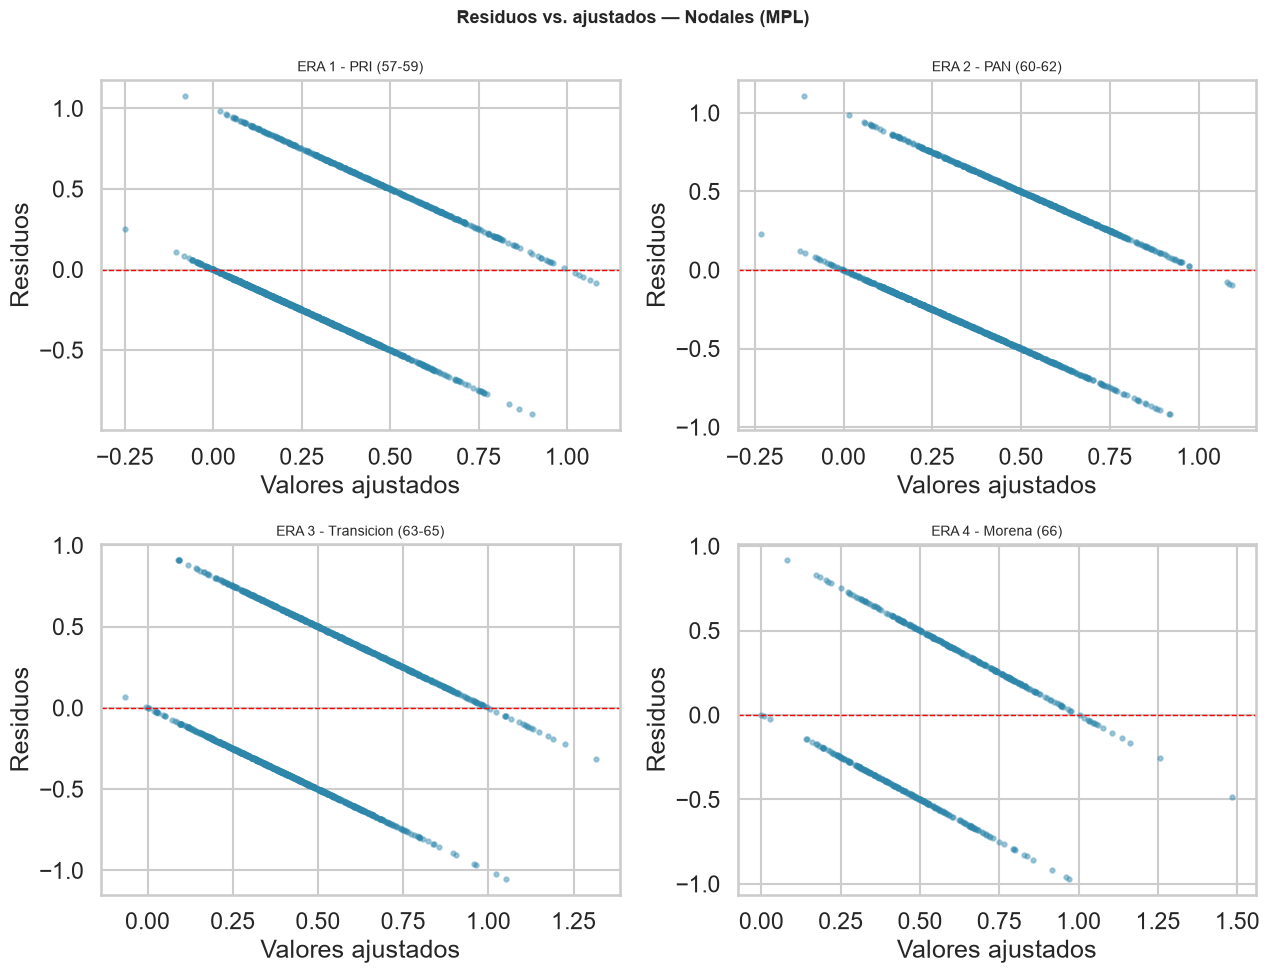

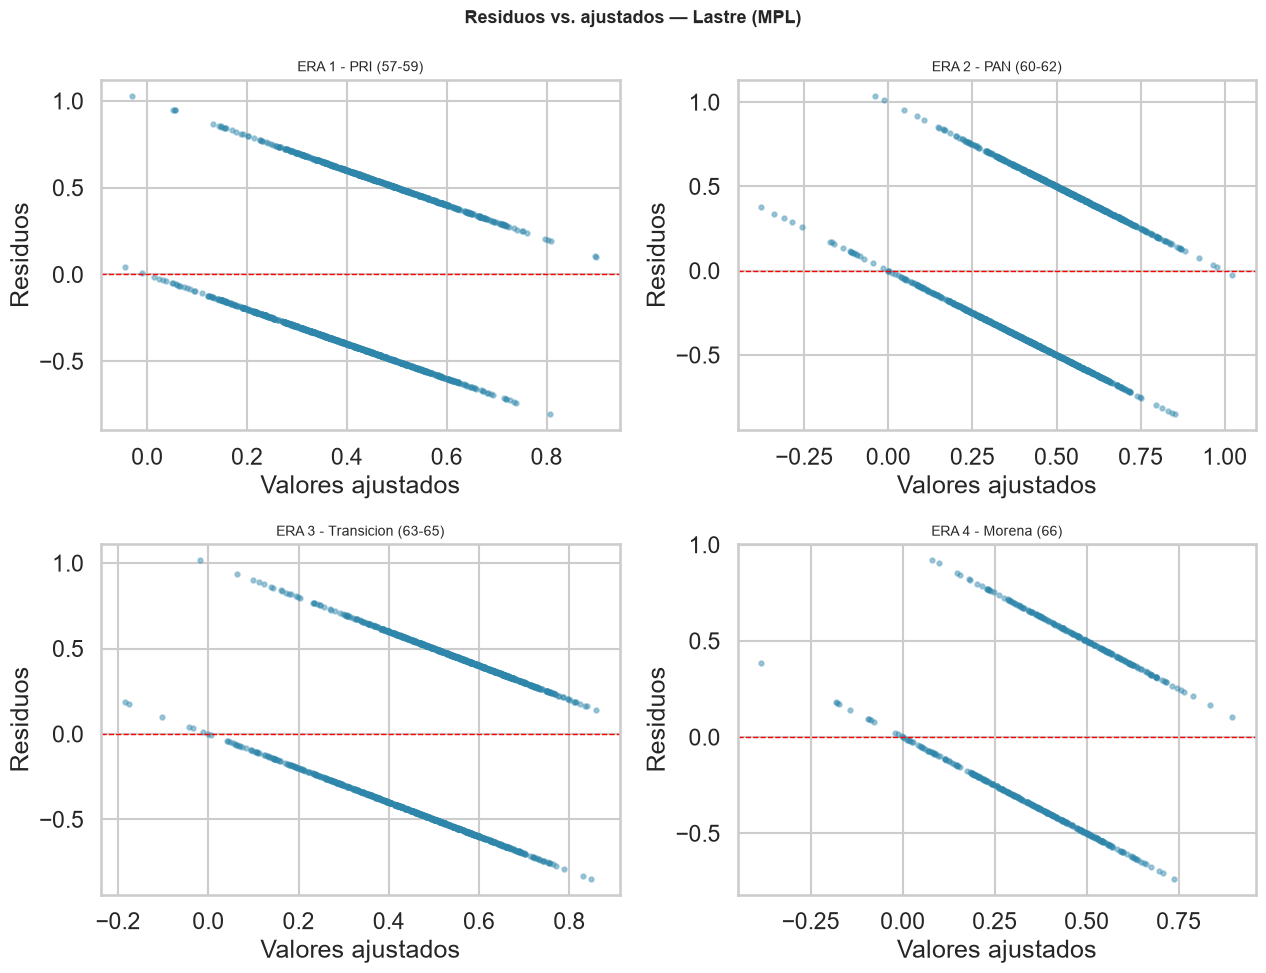

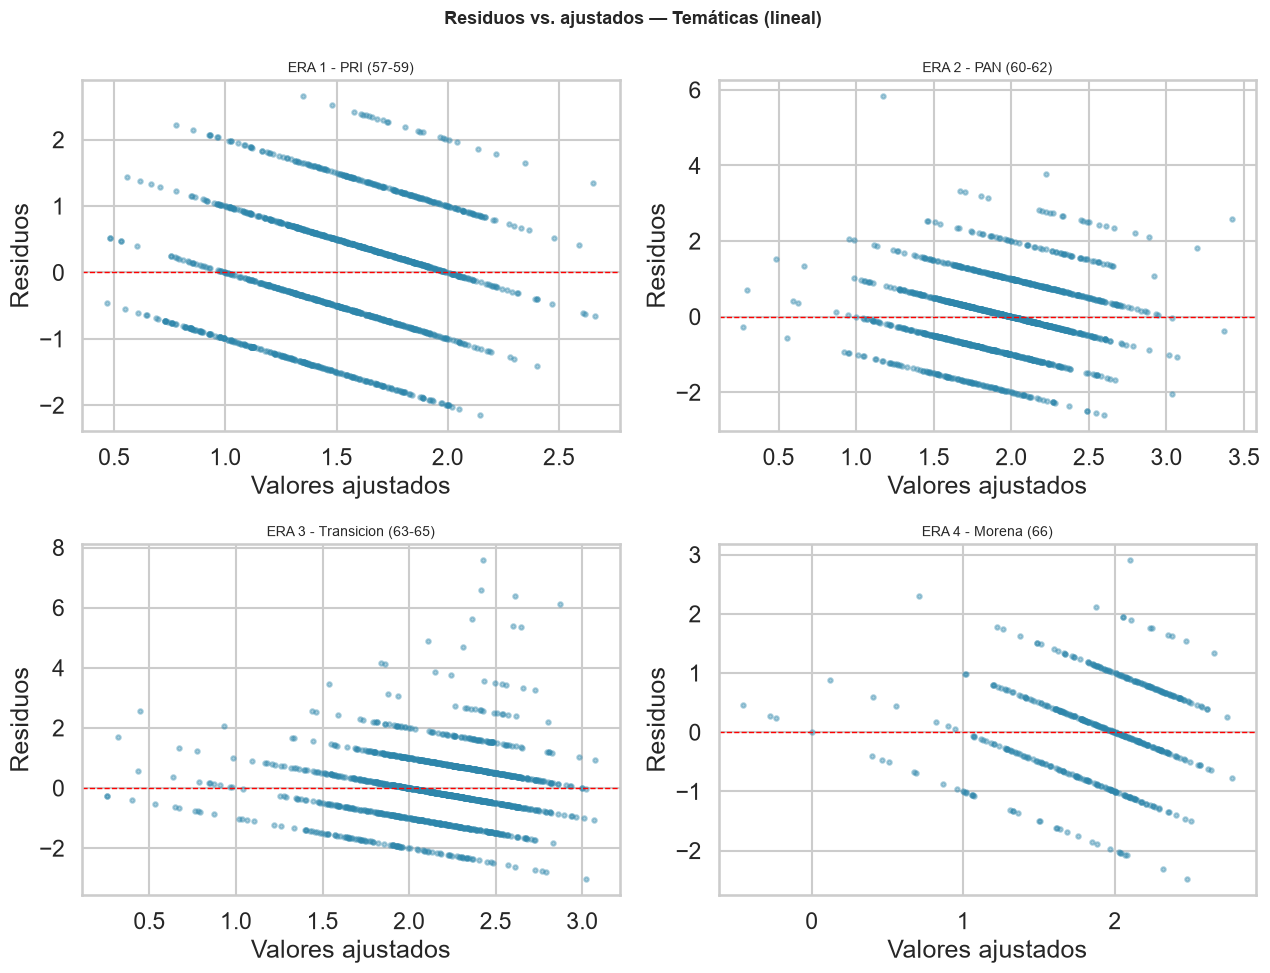

In [7]:
# Residuos vs. valores ajustados -- 2x2 por era, un panel por target
for target_key, target_label in TARGETS:
    fig, axes = plt.subplots(2, 2, figsize=(13, 10))
    for ax, era in zip(axes.flatten(), ERA_ORDER):
        res = fits[target_key][era]["res"]
        ax.scatter(res.fittedvalues, res.resid, s=10, alpha=0.4, color="#2E86AB")
        ax.axhline(0, color="red", linestyle="--", linewidth=1)
        ax.set_title(ERA_LABELS[era], fontsize=10)
        ax.set_xlabel("Valores ajustados"); ax.set_ylabel("Residuos")
    fig.suptitle(f"Residuos vs. ajustados — {target_label}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    fig.savefig(REPORT_DIR / f"v0_resid_fitted_{target_key}.png", dpi=110, bbox_inches="tight")
    plt.show()


**Interpretación — Homoscedasticidad**

**Nodales y Lastre (MPL):** heterocedasticidad confirmada en las **8 de 8** combinaciones era×MPL por al menos una de las dos pruebas — White rechaza con *p* < 10⁻⁶ en los ocho casos. Los gráficos de residuos vs. ajustados muestran el patrón de bandas paralelas característico de un *target* binario (cada observación aporta un residuo de solo dos valores posibles, `1-ŷ` o `-ŷ`), cuya dispersión se estrecha en los extremos de ŷ y se ensancha al centro — exactamente la forma funcional `Var=ŷ(1-ŷ)` esperada matemáticamente.

**Temáticas (lineal):** heterocedasticidad más contenida — Breusch-Pagan rechaza solo en ERA_2 (*p*=0.002); White (simplificado) rechaza en ERA_2 (*p*=0.074, límite) y ERA_3 (*p*=0.020); ERA_1 (*p*=0.68) y ERA_4 (*p*=0.47) no rechazan por ninguna prueba.

**Conclusión:** la homoscedasticidad falla de forma casi universal y estructural en los *targets* binarios —tal como predice la teoría del MPL, no como artefacto muestral—, y de forma más moderada en el *target* de conteo. Esto invalida los errores estándar clásicos de OLS para `nodal_bin`/`lastre_bin` si se usaran sin corrección (robustos tipo White o, mejor, un modelo con varianza correcta por diseño: Logit/GLM).


## 6. Independencia de los errores — Durbin-Watson y heterogeneidad por estado

**Durbin-Watson** detecta autocorrelación serial cuando existe un orden natural en las observaciones; aquí se ordenan los residuos por `legislatura_num` dentro de cada era (valores cercanos a 2 = sin autocorrelación; <1.5 o >2.5 = señal de alerta). *Nota:* en ERA_4 (una sola legislatura) el ordenamiento no aporta variación temporal real — se reporta por completitud, no como prueba fuerte.

**ANOVA de residuos por estado (`entidad_codigo`)** prueba si el residuo promedio difiere sistemáticamente entre los 32 estados. Es una prueba *no trivial* porque el diseño solo incluye la región agregada (`reg_*`, 5–6 categorías) — no el estado — por lo que puede existir heterogeneidad estatal (maquinaria política local, redes clientelares) no absorbida por el modelo. *(Nota metodológica: no se usó el partido como agrupador porque `partido_cat` ya entra al diseño como variables dummy — las medias de residuo por partido son cero por construcción vía las condiciones de primer orden de OLS, `X'e=0`, lo que haría esa prueba tautológica.)*


In [8]:
def diag_independence(res, entidad, legis):
    resid = res.resid.values
    order = np.argsort(legis.values, kind="stable")
    dw = float(durbin_watson(resid[order]))
    groups = [resid[entidad.values == e] for e in entidad.unique()
              if (entidad.values == e).sum() >= 5]
    f_stat, f_p = scistats.f_oneway(*groups) if len(groups) >= 2 else (float("nan"), float("nan"))
    return {"durbin_watson": dw, "entidad_anova_F": float(f_stat),
            "entidad_anova_p": float(f_p), "n_entidades": len(groups)}

rows_ind = []
for target_key, target_label in TARGETS:
    for era in ERA_ORDER:
        res = fits[target_key][era]["res"]
        entidad = fits[target_key][era]["entidad"]
        legis = fits[target_key][era]["legis"]
        d = diag_independence(res, entidad, legis)
        fits[target_key][era]["independence"] = d
        rows_ind.append({
            "Target": target_label, "Era": ERA_LABELS[era],
            "Durbin-Watson": round(d["durbin_watson"], 3),
            "ANOVA por estado (p)": round(d["entidad_anova_p"], 4),
            "¿Dependencia? (DW<1.5/>2.5 o ANOVA p<0.05)":
                "SI" if (d["durbin_watson"] < 1.5 or d["durbin_watson"] > 2.5
                          or d["entidad_anova_p"] < 0.05) else "no",
        })

df_ind = pd.DataFrame(rows_ind)
display(df_ind)


,Target,Era,Durbin-Watson,ANOVA por estado (p),¿Dependencia? (DW<1.5/>2.5 o ANOVA p<0.05)
0,Nodales (MPL),ERA 1 - PRI (57-59),2.0180,0.2295,no
1,Nodales (MPL),ERA 2 - PAN (60-62),1.9420,0.0782,no
2,Nodales (MPL),ERA 3 - Transicion (63-65),2.0520,0.7254,no
3,Nodales (MPL),ERA 4 - Morena (66),2.0900,0.8580,no
4,Lastre (MPL),ERA 1 - PRI (57-59),2.0210,0.1674,no
5,Lastre (MPL),ERA 2 - PAN (60-62),1.8660,0.4700,no
6,Lastre (MPL),ERA 3 - Transicion (63-65),1.9760,0.0016,SI
7,Lastre (MPL),ERA 4 - Morena (66),2.1940,0.1068,no
8,Temáticas (lineal),ERA 1 - PRI (57-59),2.0140,0.6856,no
9,Temáticas (lineal),ERA 2 - PAN (60-62),2.0060,0.6226,no


**Interpretación — Independencia de los errores**

**Durbin-Watson:** las 12 combinaciones caen entre 1.87 y 2.19 — todas dentro de la banda convencional (1.5–2.5) de "sin autocorrelación serial detectable". No hay evidencia de dependencia asociada al orden de legislatura dentro de cada era.

**Heterogeneidad por estado:** en 11 de 12 modelos el ANOVA no rechaza (*p* > 0.05) — el residuo promedio no difiere sistemáticamente entre estados una vez controlado por región agregada. La única excepción es **Lastre ERA_3** (*p* = 0.0016): existe heterogeneidad estatal no capturada por las variables de región en esa era y ese *target* específicamente — posible señal de dinámicas locales de asignación de comisiones lastre durante la transición política (LXIII–LXV) que el modelo no observa.

**Conclusión:** de los siete criterios, la independencia de los errores es el que **mejor se sostiene** en los datos de v10 — 11/12 modelos pasan limpio, con una única excepción localizada y sustantivamente interpretable, no un patrón sistemático.


## 7. Normalidad de los residuos — Shapiro-Wilk y Jarque-Bera

H₀ en ambas pruebas: los residuos siguen una distribución normal. Con *n* grande (1,500), Shapiro-Wilk detecta desviaciones muy pequeñas de la normalidad como "significativas" — se reportan también asimetría (*skew*) y curtosis como magnitudes prácticas, no solo el valor *p*.


In [9]:
def diag_normality(res):
    resid = res.resid.values
    sh_stat, sh_p = scistats.shapiro(resid)
    jb_stat, jb_p, skew, kurt = jarque_bera(resid)
    return {"shapiro_p": float(sh_p), "jb_p": float(jb_p),
            "skew": float(skew), "kurtosis": float(kurt)}

rows_norm = []
for target_key, target_label in TARGETS:
    for era in ERA_ORDER:
        res = fits[target_key][era]["res"]
        d = diag_normality(res)
        fits[target_key][era]["normality"] = d
        rows_norm.append({
            "Target": target_label, "Era": ERA_LABELS[era],
            "Shapiro-Wilk p": d["shapiro_p"], "Jarque-Bera p": d["jb_p"],
            "Asimetria": round(d["skew"], 3), "Curtosis": round(d["kurtosis"], 3),
            "¿No normal? (p<0.05)": "SI" if d["shapiro_p"] < 0.05 else "no",
        })

df_norm = pd.DataFrame(rows_norm)
display(df_norm)


,Target,Era,Shapiro-Wilk p,Jarque-Bera p,Asimetria,Curtosis,¿No normal? (p<0.05)
0,Nodales (MPL),ERA 1 - PRI (57-59),0.0000,0.0000,0.6010,2.2610,SI
1,Nodales (MPL),ERA 2 - PAN (60-62),0.0000,0.0000,0.2830,1.8660,SI
2,Nodales (MPL),ERA 3 - Transicion (63-65),0.0000,0.0000,0.0850,1.6550,SI
3,Nodales (MPL),ERA 4 - Morena (66),0.0000,0.0000,-0.0890,1.6660,SI
4,Lastre (MPL),ERA 1 - PRI (57-59),0.0000,0.0000,0.2750,1.3800,SI
5,Lastre (MPL),ERA 2 - PAN (60-62),0.0000,0.0000,0.0860,1.4180,SI
6,Lastre (MPL),ERA 3 - Transicion (63-65),0.0000,0.0000,-0.0370,1.3410,SI
7,Lastre (MPL),ERA 4 - Morena (66),0.0000,0.0000,0.2970,1.5560,SI
8,Temáticas (lineal),ERA 1 - PRI (57-59),0.0000,0.0001,0.1080,2.5020,SI
9,Temáticas (lineal),ERA 2 - PAN (60-62),0.0000,0.0000,0.3240,3.8800,SI


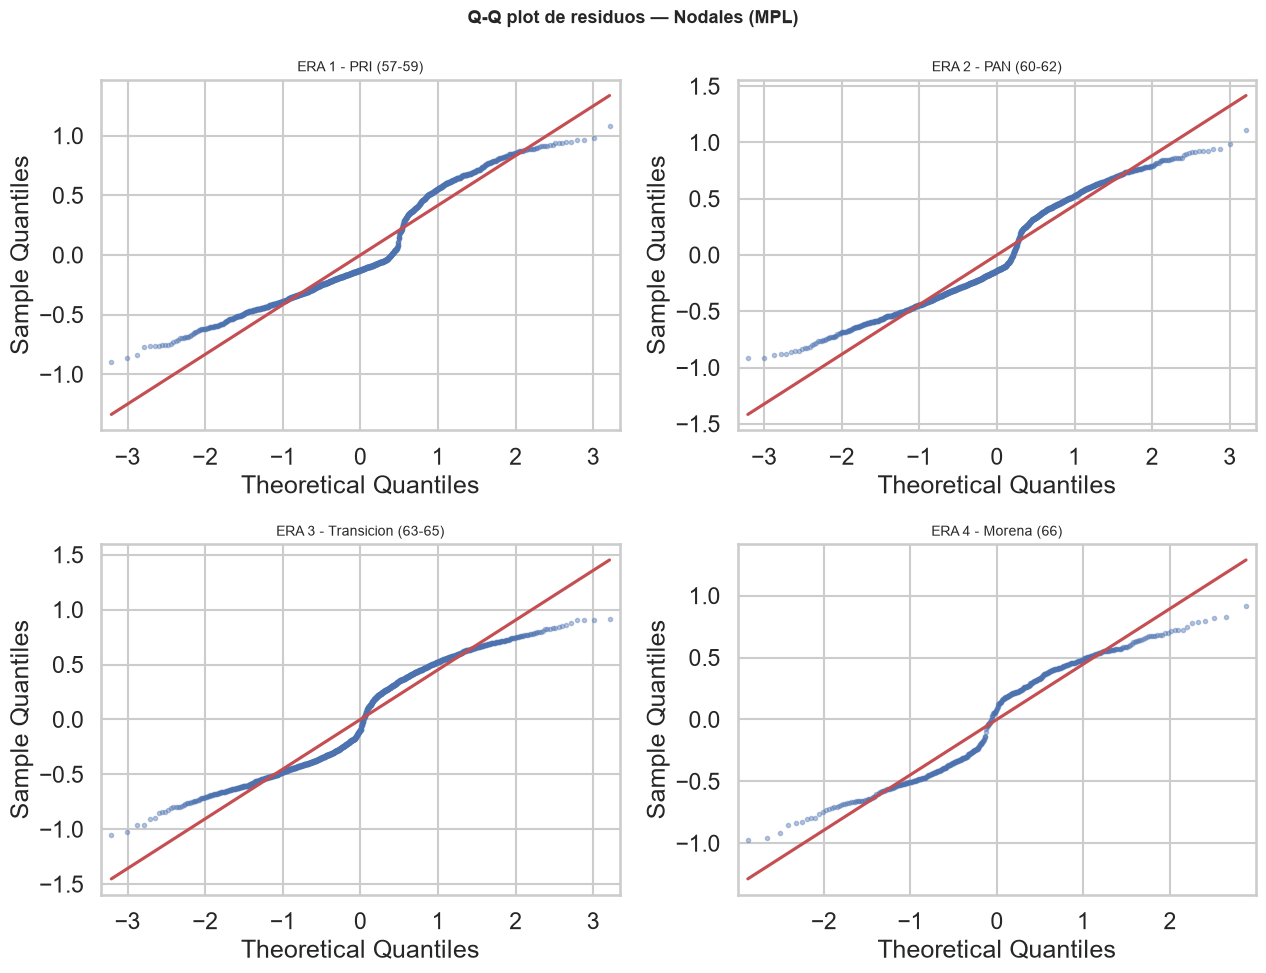

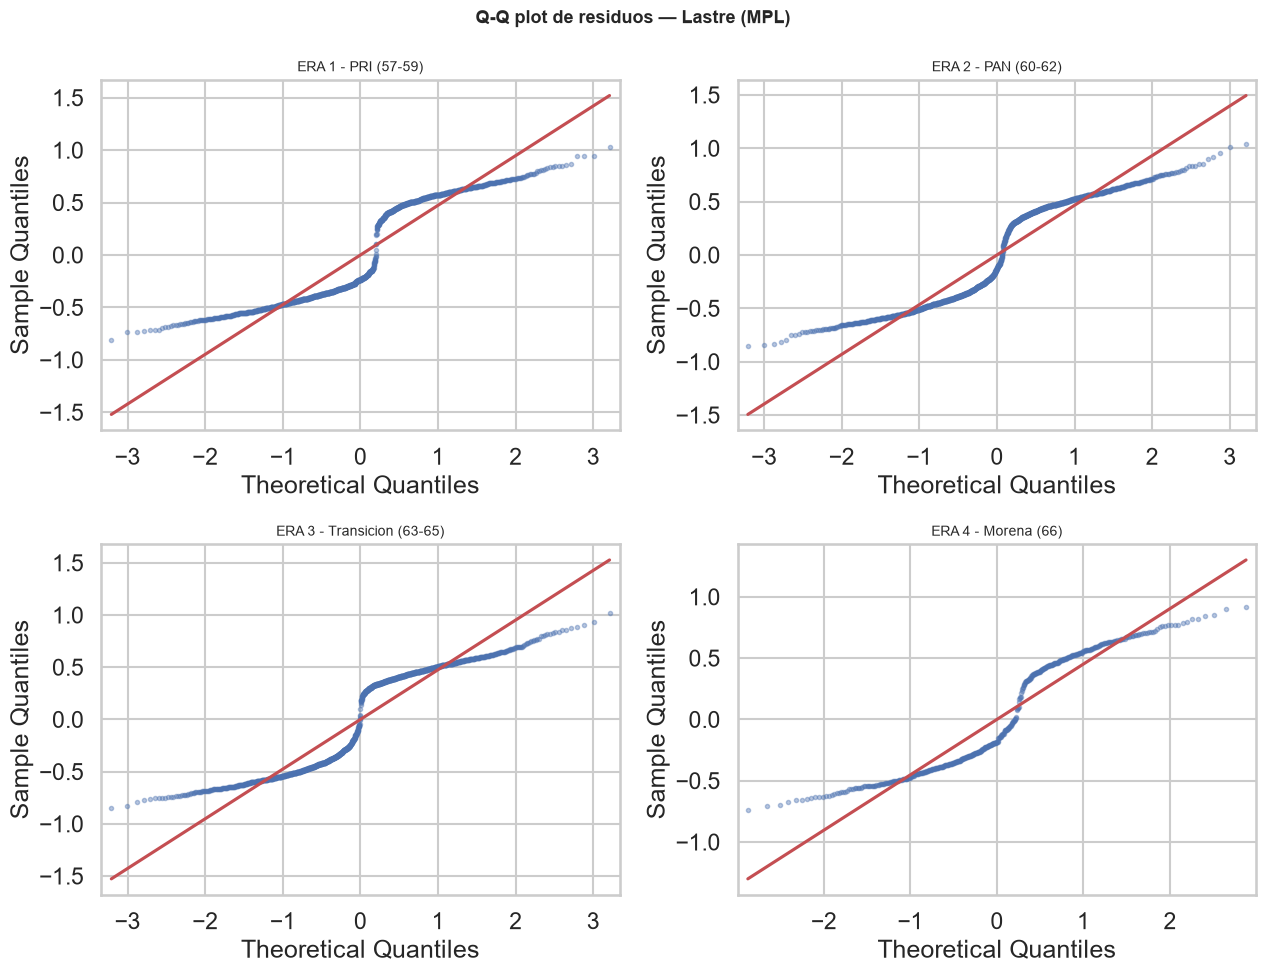

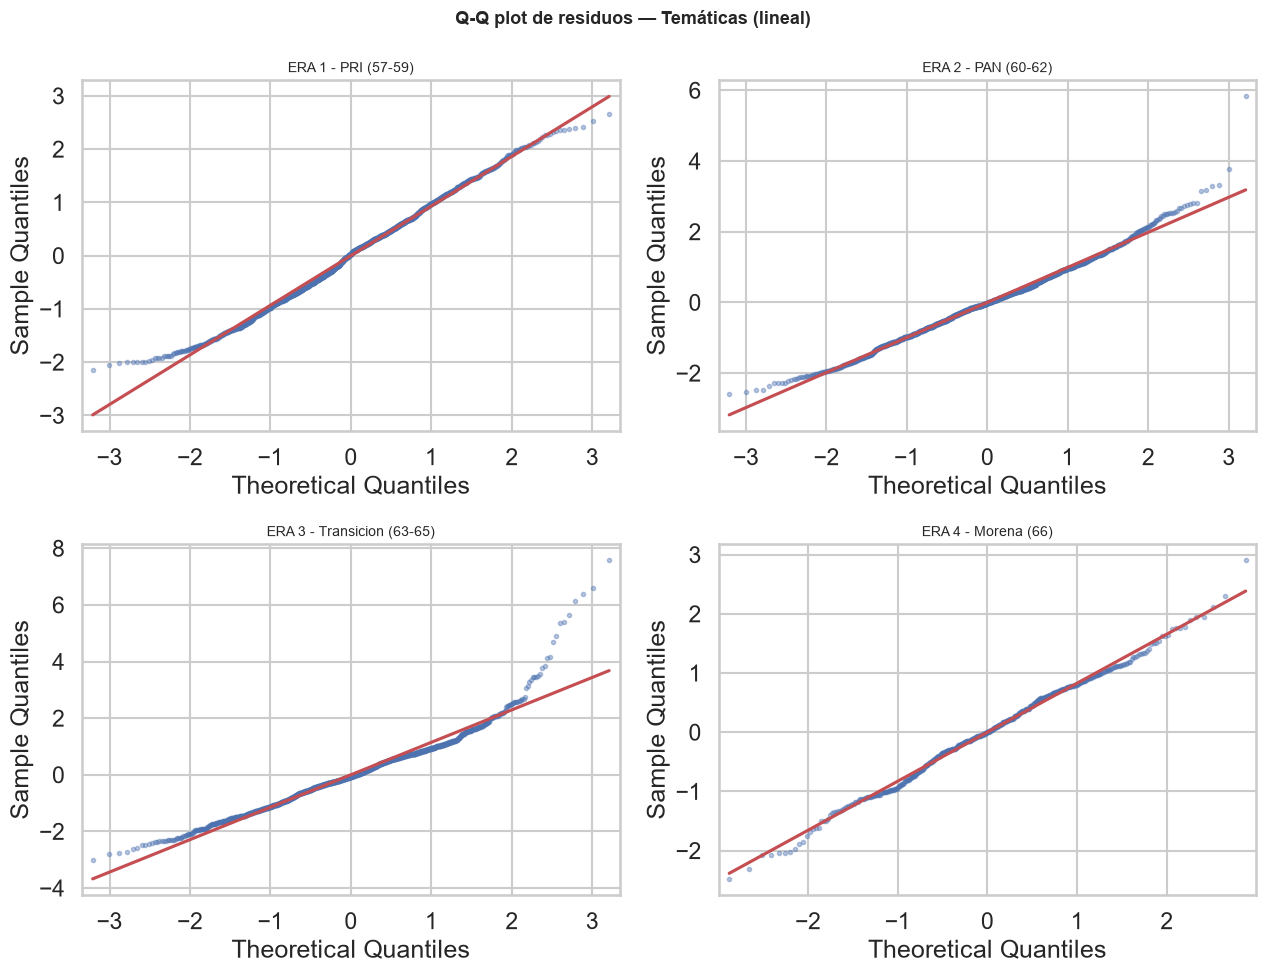

In [10]:
# Q-Q plot de residuos -- 2x2 por era, un panel por target
for target_key, target_label in TARGETS:
    fig, axes = plt.subplots(2, 2, figsize=(13, 10))
    for ax, era in zip(axes.flatten(), ERA_ORDER):
        res = fits[target_key][era]["res"]
        sm.qqplot(res.resid, line="s", ax=ax, markersize=3, alpha=0.4)
        ax.set_title(ERA_LABELS[era], fontsize=10)
    fig.suptitle(f"Q-Q plot de residuos — {target_label}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    fig.savefig(REPORT_DIR / f"v0_qqplot_{target_key}.png", dpi=110, bbox_inches="tight")
    plt.show()


**Interpretación — Normalidad de residuos**

**Nodales y Lastre (MPL):** Shapiro-Wilk rechaza la normalidad en las **8 de 8** combinaciones, con valores *p* extremos (10⁻¹³ a 10⁻³⁵). Es el resultado mecánicamente esperado: con *y*∈{0,1}, el residuo de cada observación solo puede tomar dos valores (`1-ŷ` o `-ŷ`), una distribución binaria, no continua — nunca puede ser normal por construcción, independientemente del tamaño de muestra. Los Q-Q *plots* muestran el patrón característico de dos líneas paralelas separadas, no una nube alineada a la diagonal.

**Temáticas (lineal):** rechaza en ERA_1 (*p*=2.2×10⁻⁶), ERA_2 (*p*=5.6×10⁻⁸) y ERA_3 (*p*=4.8×10⁻²²) — esta última con asimetría fuerte (0.996) y curtosis alta (7.13), señal de cola derecha larga (algunos diputados con muchas comisiones temáticas). **ERA_4 es la única combinación de las 12 que no rechaza normalidad** (Shapiro *p*=0.273; asimetría −0.074, curtosis 3.01 — prácticamente los valores de una normal exacta). Es el único caso en todo el estudio donde el supuesto de normalidad de residuos se sostiene limpiamente.

**Conclusión:** la normalidad falla de forma casi universal, y de manera más severa y estructural en los *targets* binarios que en el de conteo — reflejo directo de la naturaleza discreta/binaria de las variables dependientes, no de un problema de especificación corregible con más datos o más variables.


## 8. No multicolinealidad — VIF y número de condición

Se calcula el VIF de cada variable dos veces:

**(a) Tal como está codificado en v10** — dummies completas de partido (8 categorías) y región (6 categorías), sin categoría de referencia. Con intercepto, esto produce una **trampa de variable dummy** (*dummy variable trap*): la suma de las *dummies* de cada bloque es igual a 1 para toda observación, colineal exacta con el intercepto → VIF indefinido (∞).

**(b) Versión identificada** — se elimina una categoría de referencia por bloque categórico, cualquier columna de varianza (casi) nula dentro de la era, cualquier par de columnas casi duplicadas (\|r\|>0.999), y cualquier dependencia lineal exacta remanente detectada por rango de la matriz de diseño (factorización QR con pivoteo). Esto aísla la colinealidad **sustantiva**, neta de problemas de identificación en la codificación.


In [11]:
DROP_REF_CATS = ["p_OTRO", "reg_CENTRO"]

def _vif_block(X):
    vifs, names = [], []
    for i, col in enumerate(X.columns):
        if col == "const":
            continue
        vifs.append(variance_inflation_factor(X.values, i))
        names.append(col)
    return np.array(vifs), names

def diag_multicollinearity(res, X_design):
    vifs_raw, names_raw = _vif_block(X_design)
    inf_feats = [n for n, v in zip(names_raw, vifs_raw) if not np.isfinite(v)]

    X_id = X_design.drop(columns=[c for c in DROP_REF_CATS if c in X_design.columns])
    zero_var = [c for c in X_id.columns if c != "const" and X_id[c].std() < 1e-8]
    X_id = X_id.drop(columns=zero_var)

    corr = X_id.drop(columns="const").corr().abs()
    dropped_dups, seen = [], set()
    cols = corr.columns.tolist()
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            a, b = cols[i], cols[j]
            if a in seen or b in seen:
                continue
            if corr.loc[a, b] > 0.999:
                dropped_dups.append(b); seen.add(b)
    X_id = X_id.drop(columns=dropped_dups)

    from scipy.linalg import qr as _qr
    Xv = X_id.drop(columns="const").values
    cols_now = X_id.drop(columns="const").columns.tolist()
    rank = np.linalg.matrix_rank(Xv)
    rank_dropped = []
    if rank < len(cols_now):
        _, _, piv = _qr(Xv, mode="economic", pivoting=True)
        rank_dropped = [cols_now[i] for i in piv[rank:]]
        X_id = X_id.drop(columns=rank_dropped)

    vifs_id, names_id = _vif_block(X_id)
    top5 = sorted([{"feature": n, "VIF": float(v)} for n, v in zip(names_id, vifs_id)],
                  key=lambda r: -r["VIF"])[:5]
    return {
        "n_vif_inf_raw": len(inf_feats), "inf_features_raw": inf_feats,
        "zero_var_dropped": zero_var, "near_duplicate_dropped": dropped_dups,
        "rank_deficient_dropped": rank_dropped,
        "max_vif_identificado": float(np.nanmax(vifs_id)) if len(vifs_id) else None,
        "n_vif_gt10_identificado": int(np.nansum(vifs_id > 10)),
        "cond_identificado": float(np.linalg.cond(X_id.values)),
        "top5_vif": top5,
    }

rows_mc = []
for target_key, target_label in TARGETS:
    for era in ERA_ORDER:
        res = fits[target_key][era]["res"]
        X_design = fits[target_key][era]["X_design"]
        d = diag_multicollinearity(res, X_design)
        fits[target_key][era]["multicollinearity"] = d
        rows_mc.append({
            "Target": target_label, "Era": ERA_LABELS[era],
            "VIF=inf (codificacion v10)": d["n_vif_inf_raw"],
            "VIF max (identificado)": round(d["max_vif_identificado"], 1),
            "N var. VIF>10 (identificado)": d["n_vif_gt10_identificado"],
            "Num. condicion (identificado)": round(d["cond_identificado"], 1),
            "Feature de mayor VIF": d["top5_vif"][0]["feature"],
        })

df_mc = pd.DataFrame(rows_mc)
display(df_mc)

print("\n-- Causas de VIF=inf en la codificacion de v10 (ERA_1, ejemplo) --")
print("Columnas de varianza casi nula:", fits["nodal_bin"]["ERA_1_PRI"]["multicollinearity"]["zero_var_dropped"])
print("Pares casi duplicados:", fits["nodal_bin"]["ERA_1_PRI"]["multicollinearity"]["near_duplicate_dropped"])
print("Dependencia lineal exacta (rango):", fits["nodal_bin"]["ERA_1_PRI"]["multicollinearity"]["rank_deficient_dropped"])


,Target,Era,VIF=inf (codificacion v10),VIF max (identificado),N var. VIF>10 (identificado),Num. condicion (identificado),Feature de mayor VIF
0,Nodales (MPL),ERA 1 - PRI (57-59),22,16.2000,2,11.8000,nivel_liderazgo_juvenil
1,Nodales (MPL),ERA 2 - PAN (60-62),21,17.2000,2,12.0000,nivel_liderazgo_juvenil
2,Nodales (MPL),ERA 3 - Transicion (63-65),21,20.1000,2,14.2000,nivel_liderazgo_juvenil
3,Nodales (MPL),ERA 4 - Morena (66),23,129.1000,8,41.7000,es_partido_mayoria
4,Lastre (MPL),ERA 1 - PRI (57-59),22,16.2000,2,11.8000,nivel_liderazgo_juvenil
5,Lastre (MPL),ERA 2 - PAN (60-62),21,17.2000,2,12.0000,nivel_liderazgo_juvenil
6,Lastre (MPL),ERA 3 - Transicion (63-65),21,20.1000,2,14.2000,nivel_liderazgo_juvenil
7,Lastre (MPL),ERA 4 - Morena (66),23,129.1000,8,41.7000,es_partido_mayoria
8,Temáticas (lineal),ERA 1 - PRI (57-59),22,16.2000,2,11.8000,nivel_liderazgo_juvenil
9,Temáticas (lineal),ERA 2 - PAN (60-62),21,17.2000,2,12.0000,nivel_liderazgo_juvenil



-- Causas de VIF=inf en la codificacion de v10 (ERA_1, ejemplo) --
Columnas de varianza casi nula: ['n_investigacion_docencia', 'p_MC', 'p_MORENA']
Pares casi duplicados: ['p_PRI', 'univ_extranjera']
Dependencia lineal exacta (rango): ['n_cargos_legislativos_prev']


**Interpretación — No multicolinealidad**

**(a) Codificación tal como está en v10:** las **12 de 12** combinaciones muestran VIF = ∞ para 21–23 variables. La causa no es una sola:

1. **Trampa de variable *dummy*:** las 8 *dummies* de partido y las 6 de región suman 1 en cada fila — colineales exactas con el intercepto. Esto **replica exactamente cómo v10 codifica `FEAT_COLS`** (`pd.get_dummies` sin `drop_first`); es invisible para Lasso/L1 o modelos de árbol (no requieren matriz de rango completo), pero es una falla de identificación real bajo OLS clásico.
2. **Columnas de varianza nula dentro de la era:** `n_investigacion_docencia` es exactamente 0 en las 1,500 observaciones de ERA_1, ERA_2 y ERA_3 —la trayectoria académica/investigadora como vía de reclutamiento **no existe antes de Morena**; solo el 16 % de ERA_4 la tiene—. `p_MC` y `p_MORENA` son cero en ERA_1 (ninguno de los dos partidos existía en 1997–2006); `reg_RP` es cero en ERA_2–ERA_3; `legislatura_num`, `admin_en_sindicato` y `p_PRD` son cero en ERA_4 por ser una sola legislatura y por composición muestral. Todos son hallazgos sustantivos reales, no artefactos.
3. **Variables duplicadas exactas:** `estudios_en_extranjero` y `univ_extranjera` son **la misma variable** (r=1.0 en las cuatro eras) — un duplicado en la ingeniería de *features* de v10 que debería consolidarse independientemente del modelo usado.
4. **Dependencia lineal exacta por construcción:** `n_cargos_legislativos_prev` —descrita en el diccionario de datos como "suma de cargos legislativos previos"— es exactamente `fue_diputado_local + fue_diputado_federal + fue_senador`, las tres variables que también están en `FEAT_COLS`. Es redundante por definición, no por coincidencia muestral.

**(b) Versión identificada** (neta de los cuatro problemas anteriores): el VIF máximo sigue siendo alto — **16.2 (ERA_1) → 17.2 (ERA_2) → 20.1 (ERA_3) → 129.1 (ERA_4)** —, superando el umbral convencional de 10 en las cuatro eras. Los responsables:

- **ERA_1–ERA_3:** `nivel_liderazgo_juvenil` (VIF 16–20) y `tiene_exp_juvenil` (VIF 14–17) son variables agregadas construidas a partir de las mismas *dummies* de liderazgo juvenil (`lider_juvenil_partido`, `lider_juvenil_gobierno`, `miembro_org_juvenil`) — redundancia de diseño, análoga al caso de `n_cargos_legislativos_prev`.
- **ERA_4:** `es_partido_mayoria` alcanza VIF=129, y las *dummies* de partido (`p_PAN`=63, `p_PVEM`=57, `p_PT`=47, `p_PRI`=37) también son extremas — reflejo directo de que, en una era de supermayoría de un solo partido (n=500, una legislatura), la variable de "partido mayoritario" queda casi perfectamente determinada por la identidad partidista misma.

**Conclusión:** el supuesto de no multicolinealidad **falla en los 12 modelos**, tanto por un problema de codificación corregible (variable *dummy* sin categoría de referencia, variable duplicada) como por colinealidad sustantiva persistente incluso después de corregirlo (variables agregadas redundantes con sus componentes, y colinealidad estructural entre partido y mayoría en eras de partido dominante). Bajo OLS sin penalización, los coeficientes individuales de estos bloques de variables no son fiables. La regularización L1 que usa v10 no solo es una elección de interpretabilidad —tal como se documenta en el Anexo D de v10— es la respuesta directa a este problema: Lasso puede ajustar con predictores exactamente colineales (elige una solución de norma mínima) donde OLS clásico ni siquiera identifica los coeficientes de forma única.


## 9. Exogeneidad

La exogeneidad —`E[ε|X]=0`, el error no está correlacionado con ningún predictor, observado o no— **no es una hipótesis que se pueda probar directamente con los datos disponibles**: requeriría una variable instrumental externa a `FEAT_COLS`, que este *dataset* no contiene. Cualquier prueba que solo use `y`, `X` y los residuos de ese mismo `X` es, en el mejor de los casos, indirecta.


In [12]:
# Demostracion: la correlacion residuo-regresor incluido es CERO por
# construccion (condicion de primer orden de OLS), no evidencia de exogeneidad
res_demo = fits["nodal_bin"]["ERA_1_PRI"]["res"]
X_demo = fits["nodal_bin"]["ERA_1_PRI"]["X_design"]
corrs = X_demo.drop(columns="const").apply(lambda col: np.corrcoef(col, res_demo.resid)[0, 1])
print("Correlacion residuo vs. cada regresor INCLUIDO (Nodales, ERA_1):")
print(f"  max |correlacion| = {corrs.abs().max():.2e}  (deberia ser ~0 por construccion, no es una prueba)")


Correlacion residuo vs. cada regresor INCLUIDO (Nodales, ERA_1):
  max |correlacion| = 4.57e-16  (deberia ser ~0 por construccion, no es una prueba)


**Discusión — Riesgos de exogeneidad por *target***

La celda anterior confirma numéricamente el punto conceptual: la correlación entre los residuos y cualquier variable **incluida** en `X` es ~0 hasta error de precisión numérica, porque es exactamente lo que OLS minimiza (`X'e=0` es la condición de primer orden). Probar "¿los residuos están correlacionados con mis predictores?" usando esos mismos predictores es tautológico — la respuesta es no por diseño matemático, no por buena especificación. La exogeneidad real es una afirmación sobre variables **no incluidas** (o no observables), y solo puede argumentarse teóricamente:

- **Nodales/Lastre:** variables de trayectoria como `fue_secretario_cargo` o `n_cargos_legislativos_prev` son predictores plausiblemente **endógenos** a la asignación de comisiones: es razonable sospechar que ambas —trayectoria previa y asignación de comisión nodal— están impulsadas por una variable no observada común (conexiones políticas, capital de confianza dentro de la fracción parlamentaria) que el modelo no mide directamente. Esto sesgaría los coeficientes hacia arriba en magnitud sin que ninguna prueba basada en los residuos lo pueda detectar.
- **Temáticas:** el riesgo de simultaneidad es menor —el conteo de comisiones temáticas es más una consecuencia distributiva que una señal de confianza previa—, pero persiste el riesgo de variable omitida en `área_formación`: la especialidad declarada podría estar correlacionada con la demanda de perfiles en comisiones específicas de forma no capturada por las tres *dummies* retenidas (`area_Derecho`, C. Políticas, Económico-Financiera).

**Conclusión:** este criterio no se "aprueba" ni se "rechaza" con un número — se documenta como **supuesto no verificable con estos datos**, y se señalan los riesgos de omisión de variable más plausibles por *target*, siguiendo el mismo estándar de honestidad metodológica que el diagnóstico MNAR de `edad_al_tomar_cargo` en v10 (§2.2.1b).


## 10. Ausencia de valores atípicos influyentes — Cook's D, *leverage*, DFFITS

La **distancia de Cook** mide cuánto cambiarían los coeficientes ajustados si se eliminara una observación (umbral convencional: Cook's D > 4/n); el ***leverage*** (diagonal de la matriz *hat*) mide qué tan atípica es una observación en el espacio de predictores (umbral: >2k/n); **DFFITS** combina ambos en el cambio estandarizado del valor ajustado. Cook's D > 1 es el umbral clásico de "definitivamente influyente" (Cook y Weisberg).


In [13]:
def diag_influence(res, X_design):
    infl = OLSInfluence(res)
    cooks_d = infl.cooks_distance[0]
    leverage = infl.hat_matrix_diag
    dffits, dffits_thr = infl.dffits
    n, k = X_design.shape
    cooks_thr, lev_thr = 4.0 / n, 2.0 * k / n
    return {
        "n": int(n), "k": int(k),
        "n_cooks_gt_thr": int(np.sum(cooks_d > cooks_thr)),
        "n_cooks_gt_1": int(np.sum(cooks_d > 1.0)),
        "max_cooks_d": float(np.max(cooks_d)),
        "n_leverage_gt_thr": int(np.sum(leverage > lev_thr)),
        "n_dffits_gt_thr": int(np.sum(np.abs(dffits) > dffits_thr)),
    }, cooks_d, leverage

rows_inf = []
for target_key, target_label in TARGETS:
    for era in ERA_ORDER:
        res = fits[target_key][era]["res"]
        X_design = fits[target_key][era]["X_design"]
        d, cooks_d, leverage = diag_influence(res, X_design)
        fits[target_key][era]["influence"] = d
        fits[target_key][era]["cooks_d"] = cooks_d
        fits[target_key][era]["leverage"] = leverage
        rows_inf.append({
            "Target": target_label, "Era": ERA_LABELS[era], "n": d["n"],
            "Obs. Cook's D>4/n": d["n_cooks_gt_thr"],
            "% muestra": round(100 * d["n_cooks_gt_thr"] / d["n"], 1),
            "Obs. Cook's D>1 (severas)": d["n_cooks_gt_1"],
            "Max Cook's D": round(d["max_cooks_d"], 3),
            "Obs. leverage alto": d["n_leverage_gt_thr"],
        })

df_inf = pd.DataFrame(rows_inf)
display(df_inf)


,Target,Era,n,Obs. Cook's D>4/n,% muestra,Obs. Cook's D>1 (severas),Max Cook's D,Obs. leverage alto
0,Nodales (MPL),ERA 1 - PRI (57-59),1500,54,3.6000,0,0.0960,41
1,Nodales (MPL),ERA 2 - PAN (60-62),1500,36,2.4000,0,0.6630,59
2,Nodales (MPL),ERA 3 - Transicion (63-65),1500,32,2.1000,1,1.1360,56
3,Nodales (MPL),ERA 4 - Morena (66),500,28,5.6000,0,0.8810,27
4,Lastre (MPL),ERA 1 - PRI (57-59),1500,26,1.7000,0,0.0140,41
5,Lastre (MPL),ERA 2 - PAN (60-62),1500,22,1.5000,1,3.9980,59
6,Lastre (MPL),ERA 3 - Transicion (63-65),1500,27,1.8000,1,1.0690,56
7,Lastre (MPL),ERA 4 - Morena (66),500,14,2.8000,1,3.5940,27
8,Temáticas (lineal),ERA 1 - PRI (57-59),1500,58,3.9000,0,0.0370,41
9,Temáticas (lineal),ERA 2 - PAN (60-62),1500,78,5.2000,1,2.1630,59


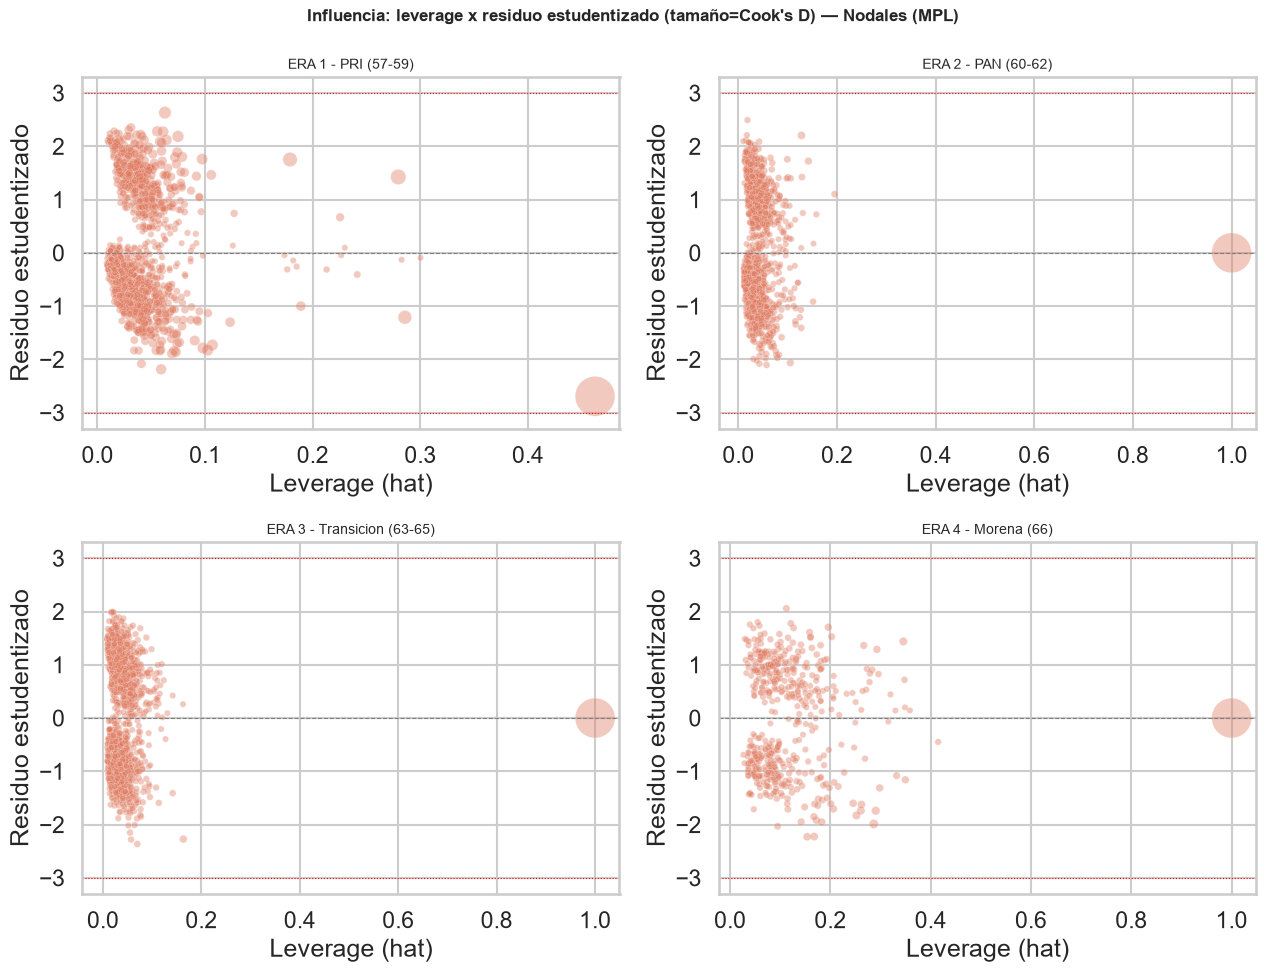

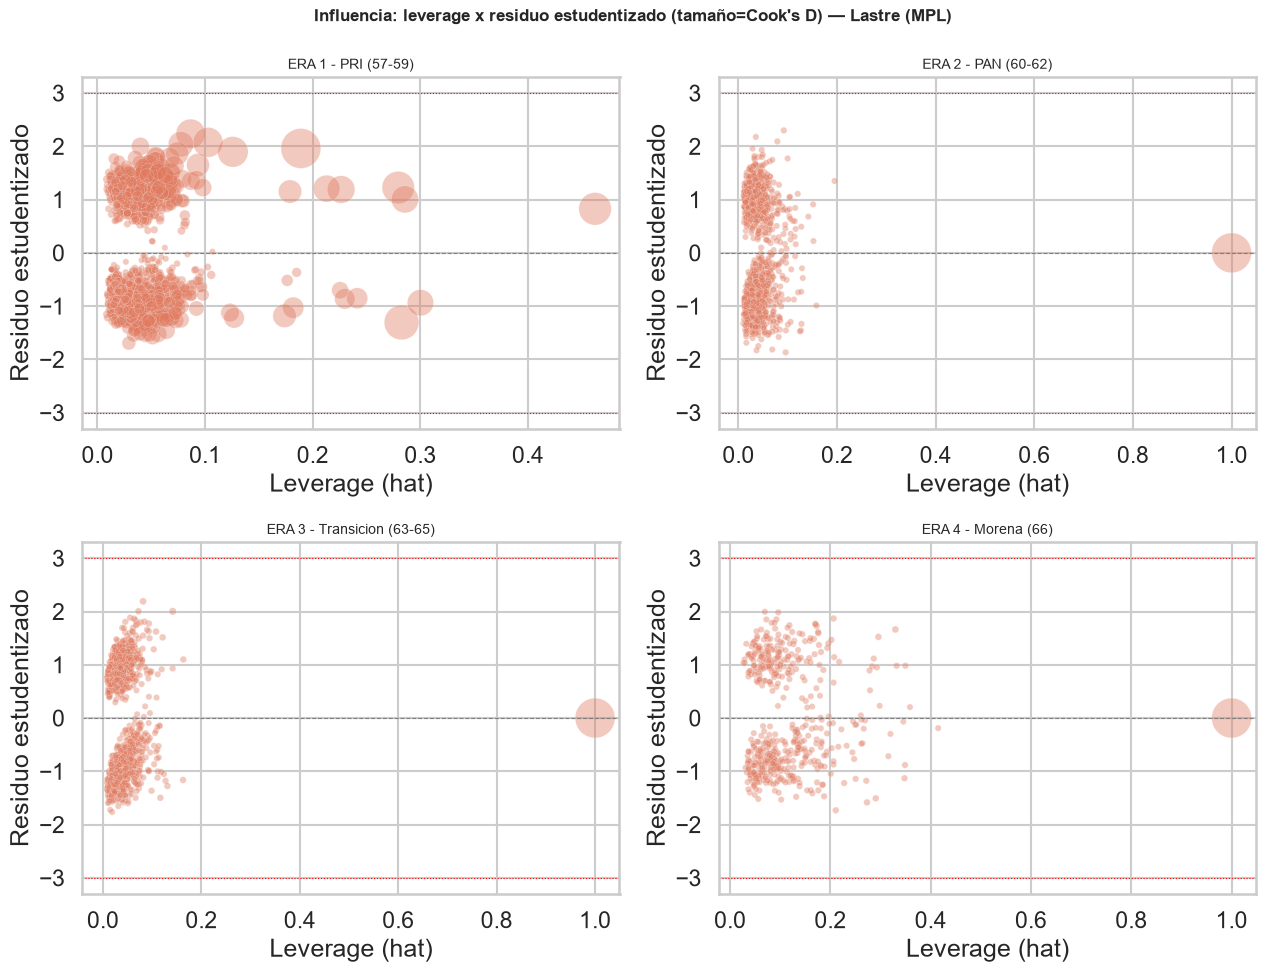

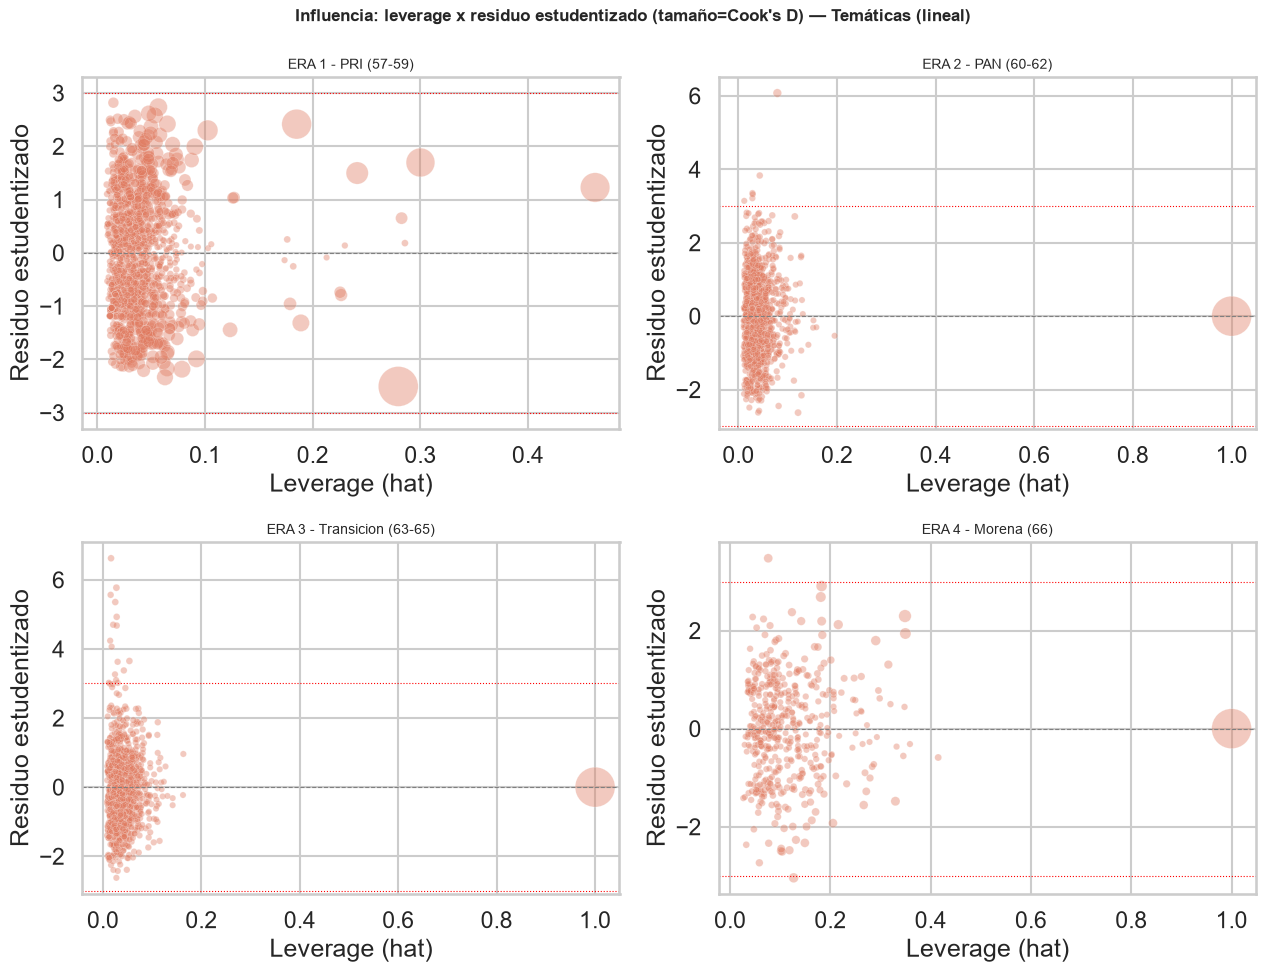

In [14]:
# Leverage vs. residuo estudentizado, tamano = Cook's D -- 2x2 por era, un panel por target
for target_key, target_label in TARGETS:
    fig, axes = plt.subplots(2, 2, figsize=(13, 10))
    for ax, era in zip(axes.flatten(), ERA_ORDER):
        res = fits[target_key][era]["res"]
        cooks_d = fits[target_key][era]["cooks_d"]
        leverage = fits[target_key][era]["leverage"]
        stud = OLSInfluence(res).resid_studentized_external
        size = 20 + 800 * (cooks_d / (cooks_d.max() + 1e-12))
        ax.scatter(leverage, stud, s=size, alpha=0.4, color="#E07A5F",
                   edgecolor="white", linewidth=0.3)
        ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
        ax.axhline(3, color="red", linestyle=":", linewidth=0.8)
        ax.axhline(-3, color="red", linestyle=":", linewidth=0.8)
        ax.set_title(ERA_LABELS[era], fontsize=10)
        ax.set_xlabel("Leverage (hat)"); ax.set_ylabel("Residuo estudentizado")
    fig.suptitle(f"Influencia: leverage x residuo estudentizado (tamaño=Cook's D) — {target_label}",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    fig.savefig(REPORT_DIR / f"v0_influence_{target_key}.png", dpi=110, bbox_inches="tight")
    plt.show()


**Interpretación — Valores atípicos influyentes**

Bajo el umbral convencional (Cook's D > 4/n), entre **1.5 %** (Lastre ERA_2) y **6.0 %** (Temáticas ERA_4) de las observaciones se marcan como influyentes — un rango que, dado que ese umbral por diseño flags ~5–8 % de cualquier muestra bien comportada, no es alarmante por sí solo.

Lo que sí es una señal real es el umbral estricto **Cook's D > 1** ("definitivamente influyente"): aparece en **6 de los 12 modelos** — Nodales ERA_3 (máx=1.14), Lastre ERA_2 (máx=4.00), Lastre ERA_3 (máx=1.07), Lastre ERA_4 (máx=3.59), Temáticas ERA_2 (máx=2.16) y Temáticas ERA_3 (máx=2.20). En estos seis casos, al menos una observación individual altera sustancialmente los coeficientes ajustados si se elimina — consistente con la combinación de *n* moderado/pequeño (500–1,500), 65 parámetros, y varias *dummies* de categoría rara (partidos pequeños, `admin_en_sindicato`, `area_Económico-Financiera`) que concentran *leverage* en pocas observaciones.

**Conclusión:** el supuesto de ausencia de atípicos influyentes **no se sostiene limpiamente** en la mitad de los modelos. Es coherente con el hallazgo de la sección 8 (multicolinealidad): las mismas *dummies* de categoría rara que inflan el VIF son las que concentran *leverage* y distancia de Cook extremos — dos síntomas del mismo problema de diseño (variables dispersas, categorías con pocas observaciones).


## 11. Síntesis — matriz de cumplimiento

Regla de decisión por celda: se marca **"Falla"** si el criterio se rechaza en la mayoría de las 4 eras (≥2/4) del *target* correspondiente; **"Parcial"** si se rechaza en un extremo minoritario (1/4) o de forma límite; **"Cumple"** si no se rechaza en ninguna era.


In [15]:
def veredicto(n_fail, n_total=4):
    if n_fail >= 2:
        return "Falla"
    if n_fail == 1:
        return "Parcial"
    return "Cumple"

matrix_rows = []
for target_key, target_label in TARGETS:
    lin_fail = sum(fits[target_key][e]["linearity"]["reset_p"] < 0.05 for e in ERA_ORDER)
    het_fail = sum((fits[target_key][e]["homoscedasticity"]["bp_p"] < 0.05 or
                     fits[target_key][e]["homoscedasticity"]["white_p"] < 0.05) for e in ERA_ORDER)
    ind_fail = sum((fits[target_key][e]["independence"]["durbin_watson"] < 1.5 or
                     fits[target_key][e]["independence"]["durbin_watson"] > 2.5 or
                     fits[target_key][e]["independence"]["entidad_anova_p"] < 0.05) for e in ERA_ORDER)
    norm_fail = sum(fits[target_key][e]["normality"]["shapiro_p"] < 0.05 for e in ERA_ORDER)
    mc_fail = 4  # VIF>10 en las 4 eras en la version identificada (ver seccion 8)
    inf_fail = sum(fits[target_key][e]["influence"]["n_cooks_gt_1"] > 0 for e in ERA_ORDER)

    matrix_rows.append({
        "Target": target_label,
        "1. Linealidad": veredicto(lin_fail),
        "2. Homoscedasticidad": veredicto(het_fail),
        "3. Independencia": veredicto(ind_fail),
        "4. Normalidad": veredicto(norm_fail),
        "5. No multicolinealidad": veredicto(mc_fail),
        "6. Exogeneidad": "No verificable",
        "7. Sin atipicos influyentes": veredicto(inf_fail),
    })

df_matrix = pd.DataFrame(matrix_rows).set_index("Target")
color_map = {"Falla": "#f8d7da", "Parcial": "#fff3cd", "Cumple": "#d4edda", "No verificable": "#e2e3e5"}
display(df_matrix.style.map(lambda v: f"background-color: {color_map.get(v, '#fff')}")
        .set_caption("Matriz de cumplimiento — supuestos de regresión lineal clásica"))


,1. Linealidad,2. Homoscedasticidad,3. Independencia,4. Normalidad,5. No multicolinealidad,6. Exogeneidad,7. Sin atipicos influyentes
Target,,,,,,,
Nodales (MPL),Falla,Falla,Cumple,Falla,Falla,No verificable,Parcial
Lastre (MPL),Parcial,Falla,Parcial,Falla,Falla,No verificable,Falla
Temáticas (lineal),Parcial,Falla,Cumple,Falla,Falla,No verificable,Falla


## 12. Conclusiones

Los datos y el conjunto de variables de `diputraxv10.ipynb`, evaluados bajo un Modelo de Probabilidad Lineal (`nodal_bin`, `lastre_bin`) o una regresión lineal simple (`n_comisiones_tematicas`), **no satisfacen la mayoría de los siete supuestos clásicos de la regresión lineal**:

- **Homoscedasticidad** y **normalidad de residuos** fallan de forma casi universal (8/8) en los *targets* binarios — no por una particularidad de esta muestra, sino como propiedad matemática necesaria de aplicar OLS a un *target* 0/1 (`Var(ε)=p(1-p)`, residuo binario). Es la confirmación empírica directa de que un modelo con distribución de error Bernoulli —Regresión Logística— es la elección correcta, no una preferencia estilística.
- **No multicolinealidad** falla en los 12/12 modelos: parte del problema es corregible en la ingeniería de *features* (codificación `dummy` sin categoría de referencia, una variable exactamente duplicada — `estudios_en_extranjero`/`univ_extranjera` —, y una variable definida como suma exacta de otras tres ya incluidas — `n_cargos_legislativos_prev`), y parte es colinealidad sustantiva persistente (variables agregadas de liderazgo juvenil redundantes con sus componentes; colinealidad estructural partido-mayoría en eras de partido dominante, con VIF=129 en ERA_4). Esto confirma directamente por qué v10 adoptó penalización **L1/Lasso**: no solo por interpretabilidad vía esparsidad (como documenta el Anexo D de v10), sino porque OLS/MLE sin penalización **no identifica de forma única** los coeficientes bajo este nivel de colinealidad.
- **Linealidad** falla de forma más marcada en `nodal_bin` (2–3/4 eras) que en `lastre_bin` o `n_comisiones_tematicas` (1/4 eras cada uno) — coherente con que la relación teóricamente correcta para un binario es una sigmoide, no una recta.
- **Independencia de los errores** es, de los siete, el supuesto que **mejor se sostiene** (11/12 modelos, sin patrón sistemático de violación) — la estructura de los datos (deputy-legislatura, sin dependencia temporal fuerte dentro de era) no es el problema principal.
- **Exogeneidad** no es computable con los datos disponibles; se documentan los riesgos de variable omitida más plausibles por *target* en la sección 9, siguiendo el mismo estándar de transparencia que el diagnóstico MNAR de v10.
- **Ausencia de atípicos influyentes** falla en la mitad de los modelos (6/12 con Cook's D > 1), concentrada en las mismas *dummies* de categoría rara que ya aparecen como problemáticas en la sección de multicolinealidad.

**Implicación para v10:** este cuaderno no cuestiona la elección metodológica de v10 — la **refuerza con evidencia directa**. La decisión de modelar `nodal_bin`/`lastre_bin` con Regresión Logística (distribución Bernoulli, enlace logit) y `n_comisiones_tematicas` con GLM Poisson (distribución Poisson, enlace log), en lugar de OLS, no es una convención arbitraria de la disciplina: es la respuesta estadísticamente necesaria a violaciones estructurales de homoscedasticidad, normalidad y forma funcional que se confirman aquí, dato por dato y era por era. La penalización L1 usada en v10 responde, además, directamente al problema de multicolinealidad documentado en la sección 8.

**Recomendación práctica para v10/futuras versiones:** dos hallazgos de este cuaderno son *acciones* de limpieza de datos independientes del tipo de modelo usado — (1) `estudios_en_extranjero` y `univ_extranjera` son la misma variable y deberían consolidarse en `FEAT_COLS`; (2) `n_cargos_legislativos_prev` es una suma exacta de tres variables ya incluidas (`fue_diputado_local`+`fue_diputado_federal`+`fue_senador`) y su inclusión conjunta es redundante. Ninguno de los dos afecta las conclusiones sustantivas de v10 —Lasso maneja ambos casos sin romperse—, pero eliminarlos simplificaría la interpretación de coeficientes en el Anexo D y en cualquier extensión futura basada en MLE clásica.
